In [13]:
import warnings
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import tracemalloc
import time
from scipy.sparse import csr_matrix
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score)

# Import custom functions
from projection_utils_sparse import project_components
from hungarian_algorithm import apply_hungarian_algorithm
from eigen_utils import compute_sorted_eigen
from clustering_utils import perform_gmm_clustering
from jspca_utils import joint_spca
from spca_utils import compute_spca
from adjacency_matrix_knn import compute_knn_matrices

# Suppress warnings
warnings.filterwarnings("ignore")

In [14]:
# Define folder path
folder_path = "/home/ines/Desktop/jsPCA/data"

# Define file paths
file1 = os.path.join(folder_path, "151673.h5ad")
file2 = os.path.join(folder_path, "151674.h5ad")

# Load datasets
adata1 = sc.read_h5ad(file1)
adata2 = sc.read_h5ad(file2)


# Remove NaNs in 'ground_truth'
adata1 = adata1[~adata1.obs['ground_truth'].isna()].copy()
adata2 = adata2[~adata2.obs['ground_truth'].isna()].copy()

# Normalize datasets
sc.pp.filter_genes(adata1, min_cells=20)
sc.pp.filter_genes(adata2, min_cells=20)

genes1 = adata1.var_names.tolist()
genes2 = adata2.var_names.tolist()

common_genes = list(set(genes1) & set(genes2))
print(f"Nombre de gènes communs: {len(common_genes)}")
adata1 = adata1[:, common_genes].copy()
adata2 = adata2[:, common_genes].copy()

sc.experimental.pp.normalize_pearson_residuals(adata1)
sc.pp.scale(adata1)
sc.experimental.pp.normalize_pearson_residuals(adata2)
sc.pp.scale(adata2)

adata_list = [adata1, adata2]

# Dynamic dataset selection, change the value of i to select a different dataset
i = 0  #  (0 for adata1, 1 for adata2, etc.)

selected_adata = adata_list[i]
X_sparse = selected_adata.X
eigenvectors = 20
num_labels = selected_adata.obs['ground_truth'].nunique()

print(f"Number of unique labels in 'ground_truth' (excluding NaN): {num_labels}")

# Start memory and time tracking
tracemalloc.start()  
start_time = time.time()

# Compute adjacency matrices
dist_matrix1, connectivity_matrix1 = compute_knn_matrices(adata1)
dist_matrix2, connectivity_matrix2 = compute_knn_matrices(adata2)


# Convert to sparse matrices
connectivity_matrix1 = csr_matrix(connectivity_matrix1)
connectivity_matrix2 = csr_matrix(connectivity_matrix2)

# Add the computed distances and connectivities to the AnnData object
adata1.obsp['distances'] = dist_matrix1
adata1.obsp['connectivities'] = connectivity_matrix1

adata2.obsp['distances'] = dist_matrix2
adata2.obsp['connectivities'] = connectivity_matrix2



# Compute SPCA matrices
A_spca1 = compute_spca(adata1)
A_spca2 = compute_spca(adata2)


print(f"A_spca1 shape: {A_spca1.shape}")
print(f"A_spca2 shape: {A_spca2.shape}")


# Performing Joint Sparse Principal Component Analysis (SPCA)
result = joint_spca(A_spca1, A_spca2, k=eigenvectors)
optimized_matrix = result['optimized_matrix']
projection_df = project_components(X_sparse, np.real(optimized_matrix), eigenvectors)
gmm_clusters = perform_gmm_clustering(projection_df, num_labels, random_state=42)

# Stop memory tracking and compute elapsed time
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Record elapsed time and memory usage
during_time = time.time() - start_time
memory = peak / 1024 / 1024  # Convert to MB

# Store the memory and time information in the `uns` attribute
selected_adata.uns['time'] = during_time
selected_adata.uns['memory'] = memory

# Add GMM cluster labels to the AnnData object
selected_adata.obs['GMM_clusters'] = gmm_clusters
selected_adata.obs['GMM_clusters_Categorical'] = pd.Categorical(gmm_clusters)

# Save the result to a new file
result_path = '/home/ines/Desktop/jsPCA/data'


#new_data.write(f'{result_path}/jsPCA_2_slices_151673.h5ad')

# Output elapsed time and memory usage
print(f"Elapsed time: {during_time:.2f} seconds")
print(f"{memory:.2f} MB")

Nombre de gènes communs: 15026
Number of unique labels in 'ground_truth' (excluding NaN): 7
Automatically selected k = 18
KNN graph construction successful!
Automatically selected k = 18
KNN graph construction successful!
A_spca1 shape: (15026, 15026)
A_spca2 shape: (15026, 15026)
U shape: (15026, 20)
S shape: (20,)
VT shape: (20, 40)
Eigenvalues of A1 in U:
[  9896.72502914   7329.02289734  10338.72270628   8142.73570955
   6579.30936507  12719.97120609  14389.39196561  10418.4838587
   8203.16840928  10098.88747717  15383.46932906  16556.77773967
   7269.69491304  24155.46476645  14559.61563259  27080.54901592
  29102.30051659  54089.84942406  44004.4187504  543730.44453561]
Eigenvalues of A2 in U:
[  9133.98730907  11530.05463619   8105.46306559  10286.42175214
  12343.27718959   6878.36052548   4952.19856656  14265.01050822
  15557.07460897  17125.88073448  15064.85752368   9799.94759035
   9952.33982102  20485.10081581  32206.17650893  32146.66726608
  48014.18870561  57027.655263

### Visualization

In [15]:
# Apply Hungarian algorithm for label matching and update AnnData object
gt_key = 'Region'  # Ground truth labels column name

# Drop NaNs before applying the Hungarian algorithm
cluster_labels = selected_adata.obs['GMM_clusters_Categorical']
valid_idx = ~selected_adata.obs[gt_key].isna() & ~cluster_labels.isna()
valid_gt_result = selected_adata.obs[gt_key][valid_idx]
valid_cluster_labels = cluster_labels[valid_idx]

# Apply the Hungarian algorithm for label matching
mapped_labels = apply_hungarian_algorithm(valid_gt_result, valid_cluster_labels)

# Create a full-length array with NaNs in the original NaN positions
full_mapped_labels = np.full(len(selected_adata), np.nan, dtype=object)
full_mapped_labels[valid_idx] = mapped_labels

# Update the AnnData object with the matched cluster labels
selected_adata.obs['GMM_clusters_Hungarian'] = pd.Categorical(full_mapped_labels, categories=selected_adata.obs[gt_key].cat.categories)


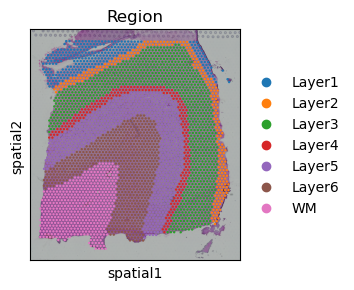

In [16]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.spatial(selected_adata, img_key="hires", color=["Region"], spot_size=100)

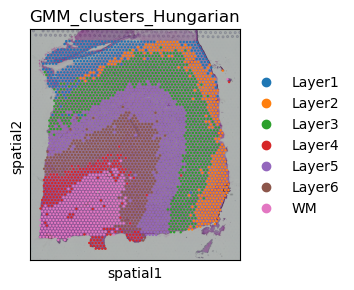

In [17]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.spatial(selected_adata, img_key="hires", color=["GMM_clusters_Hungarian"], spot_size=100)

In [18]:
# Compute ARI (Adjusted Rand Index)
obs_df = selected_adata.obs.dropna()
ari = adjusted_rand_score(obs_df['GMM_clusters_Hungarian'], obs_df['ground_truth'])
nmi = normalized_mutual_info_score(obs_df['GMM_clusters_Hungarian'], obs_df['ground_truth'])
print(f'ARI: {ari}')
print(f'NMI: {nmi}')

ARI: 0.5896898474483779
NMI: 0.6684721325255536


In [19]:
# Save ARI and NMI to an Excel file
ari_nmi_df = pd.DataFrame({'ARI': [ari], 'NMI': [nmi]})
ari_nmi_df.to_excel('/home/ines/Desktop/jsPCA/data/jsPCA_2_slices_151673_metrics.xlsx', index=False)

# Save time and memory usage to another Excel file
performance_df = pd.DataFrame({'Time (seconds)': [during_time], 'Memory (MB)': [memory]})
performance_df.to_excel('/home/ines/Desktop/jsPCA/data/jsPCA_2_slices_151673_scalability.xlsx', index=False)

print("Results successfully saved to Excel files.")

Results successfully saved to Excel files.
